In [1]:
# Parameters
eval_start = "2024-08-01"
eval_end = "2024-09-15"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

params_path_new = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28.npz'
norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/gc_norms/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 35, 65
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'


In [3]:
"""
Complete evaluation of forecast against different datasets
"""
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
# import pynvml

import jax
import optax

sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn
print(sys.path)
sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg

# current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# # jax.config.update('jax_disable_jit', True)
# # for memory efficiency
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# mean_by_level = None
# stddev_by_level = None
# diffs_stddev_by_level = None
# model_config = None
# task_config = None
# params = None
# state = None

ModuleNotFoundError: No module named 'save_params_utils'

In [ ]:
select_time_evals = []

if dataset_choice == "imerg":
    apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/'
    dbase,_ = trainer.dataloader.open_databases(apath,None) # Note no need for a separate verification dbase
    dbase = construct_era5_imerg(dbase)
    eval_time_ds = dbase.sel(time=slice(eval_start, eval_end))
    del dbase


input_vars = ['10m_u_component_of_wind',
            'geopotential_at_surface',
            '10m_v_component_of_wind',
            'specific_humidity',
            'land_sea_mask',
            'vertical_velocity',
            'geopotential',
            'v_component_of_wind',
            'temperature',
            'total_precipitation_6hr',
            'mean_sea_level_pressure',
            '2m_temperature',
            'u_component_of_wind']

eval_time_ds = eval_time_ds.expand_dims(batch=1)
eval_time_ds = eval_time_ds.rename({'latitude': 'lat', 'longitude': 'lon'})

datetime_array = eval_time_ds['time'].values
# Calculate the time coordinate in 6-hour increments (in nanoseconds)
time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

# Add the new 'time' coordinate to the dataset
final_eval_ds = eval_time_ds.assign_coords(datetime=('time', time_array))

temp_time = final_eval_ds.coords["time"].copy()
temp_datetime = final_eval_ds.coords["datetime"].copy()

# Reassign the coordinates, swapping their values
final_eval_ds = final_eval_ds.assign_coords(
    time=temp_datetime,
    datetime=temp_time
)

# final_eval_ds['geopotential_at_surface'] = final_eval_ds['geopotential_at_surface'].isel(batch=0, time=0)
# final_eval_ds['land_sea_mask'] = final_eval_ds['land_sea_mask'].isel(batch=0, time=0)

old_datetime = final_eval_ds["datetime"].values  # shape (1489,)

# For our purposes, we want the coordinate to have shape (batch, time). Since the batch
# dimension is of length 1, we can simply add a new axis.
new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

# Now, reassign the "datetime" coordinate to have dims ("batch", "time").
final_eval_ds = final_eval_ds.assign_coords(datetime=(("batch", "time"), new_datetime))

print(f"Coordinates after reassigning: {final_eval_ds.coords}\n")
final_eval_ds

Found ['/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/02', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/03', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/04', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/05', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/06', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/07', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/08', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/09', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/10', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/11', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/12', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/02', '/Datastorage

Looping through era5 days for conversion:  72%|███████▏  | 625/871 [00:11<00:04, 56.20it/s]


Exceeded IMERG timespan, stopped replacing with IMERG
✅ All ERA5 6-hourly values match the converted IMERG values (where IMERG is valid).
Coordinates after reassigning: Coordinates:
    expver    (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * level     (level) uint64 296B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number    int64 8B 0
    datetime  (batch, time) datetime64[ns] 1kB 2024-08-01 ... 2024-09-15T18:0...
  * time      (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 45 days 18:00:00



<xarray.Dataset> Size: 11GB
Dimensions:                  (batch: 1, time: 184, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 1kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 4...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
select_time_eval = final_eval_ds
select_time_eval

<xarray.Dataset> Size: 11GB
Dimensions:                  (batch: 1, time: 184, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 1kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 4...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
data_len = len(select_time_eval.time.values)
data_len

184

In [7]:
select_time_evals = []
for time_slice in range(0, data_len, 28):
    select_time_evals.append(select_time_eval.isel(time=slice(time_slice, time_slice+28)))

In [8]:
for ds in select_time_evals:
    print(ds.datetime.values[0][0])

2024-08-01T00:00:00.000000000
2024-08-08T00:00:00.000000000
2024-08-15T00:00:00.000000000
2024-08-22T00:00:00.000000000
2024-08-29T00:00:00.000000000
2024-09-05T00:00:00.000000000
2024-09-12T00:00:00.000000000


In [9]:
sims = len(select_time_evals)
sims

7

In [10]:
eval_trial_batches = []
from dask.diagnostics import ProgressBar
for i in tqdm(range(sims-1)):
    with ProgressBar():
        eval_trial_batches.append(select_time_evals[i].load())

  0%|          | 0/6 [00:00<?, ?it/s]

[########################################] | 100% Completed | 1.90 sms


 17%|█▋        | 1/6 [00:02<00:11,  2.33s/it]

[########################################] | 100% Completed | 1.87 sms


 33%|███▎      | 2/6 [00:04<00:09,  2.32s/it]

...

 67%|██████▋   | 4/6 [00:09<00:04,  2.27s/it]

[########################################] | 100% Completed | 1.78 sms


 83%|████████▎ | 5/6 [00:11<00:02,  2.26s/it]

[########################################] | 100% Completed | 1.75 sms


100%|██████████| 6/6 [00:13<00:00,  2.27s/it]


In [ ]:
# print(f"Eval batch first time: {eval_trial_batch.time.values[0]}")


with open(params_path_old, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params

with open(f'{norms_dir}diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()

state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
'params': ckpt.params,
'state': {},
'model_config': ckpt.model_config,
'task_config': ckpt.task_config,
'mean_by_level': mean_by_level,
'stddev_by_level': stddev_by_level,
'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets_template,
    forcings=forcings,
    params=params,
    state=state
)
    return predictions

In [ ]:
# need to make sure that the .npz and the .opt are both new and .opt isnt the old one
import os
import numpy as np
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from graphcast import checkpoint, graphcast

params_test = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2014-06-08_2014-07-30_FORECAST28_india_mask_buffer_expt1_6hourly.npz'
print(params_test)
f = open(params_test, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params
f.close()
params_keys_list = list(new_params.keys())
any_not_nan = any(not np.isnan(x) for x in list(new_params[f'{params_keys_list[0]}'].values())[1])
if not any_not_nan:
    print("All values are NaN")
else:
    print("Valid values are there!")
# !ls -lth /Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz

ModuleNotFoundError: No module named 'graphcast'

Eval batch time dimensions: 28
Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


100%|██████████| 16/16 [00:03<00:00,  4.74it/s]


[array(1.3510943e-05, dtype=float32), array(2.1307229e-05, dtype=float32), array(2.0082916e-05, dtype=float32), array(1.6639211e-05, dtype=float32), array(1.3939279e-05, dtype=float32), array(2.4835983e-05, dtype=float32), array(2.5134497e-05, dtype=float32), array(2.030509e-05, dtype=float32), array(1.822999e-05, dtype=float32), array(1.4289833e-05, dtype=float32), array(1.4690516e-05, dtype=float32), array(1.1537688e-05, dtype=float32), array(9.826647e-06, dtype=float32), array(1.0393642e-05, dtype=float32), array(1.0832929e-05, dtype=float32), array(9.452868e-06, dtype=float32)]
[array(7.3482124e-06, dtype=float32), array(1.7530561e-05, dtype=float32), array(1.5095897e-05, dtype=float32), array(1.251794e-05, dtype=float32), array(1.060138e-05, dtype=float32), array(2.0857493e-05, dtype=float32), array(1.7885168e-05, dtype=float32), array(1.5455418e-05, dtype=float32), array(1.4765296e-05, dtype=float32), array(1.2416066e-05, dtype=float32), array(1.199221e-05, dtype=float32), array(

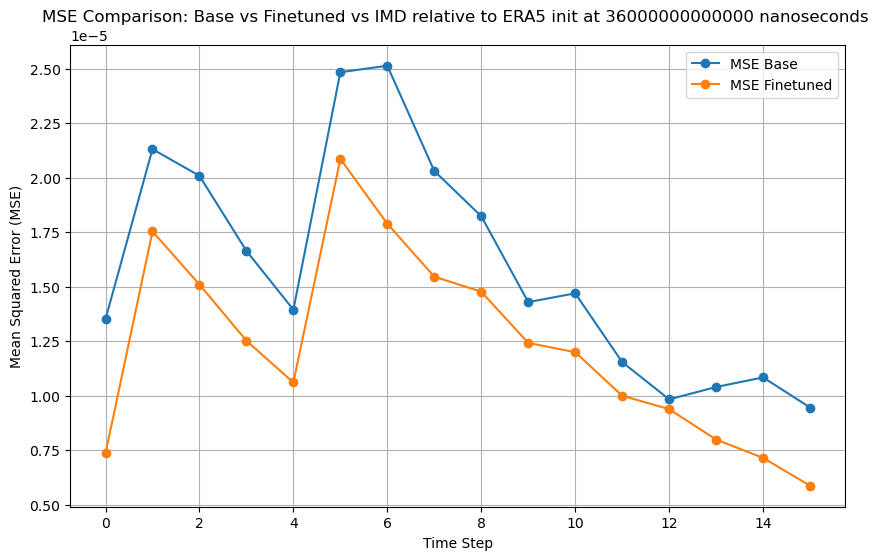

<Figure size 640x480 with 0 Axes>

In [ ]:
from plotting import compute_difference_with_targets_sims
from utils import compute_mse, compute_mse_diffs

time_len = len(eval_trial_batches[0].time.values)
eval_sim_data = eval_trial_batches[0].isel(time=slice(0, time_len-1))
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_sim_data, target_lead_times=slice("6h", "100h"),
**dataclasses.asdict(task_config))
forecast_len = len(eval_targets.time.values)

assert eval_trial_batches[0].sizes["time"] >= 3

print(f"Eval batch time dimensions: {eval_trial_batches[0].sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


diff_fine, diff_old = [], []
for time_step in tqdm(range(forecast_len)):
    diff_fine.append(compute_difference_with_targets_sims(predictions_finetuned,eval_targets,time_step, 'total_precipitation_6hr', plots_dir='plots_dir'))
    diff_old.append(compute_difference_with_targets_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr', plots_dir='plots_dir'))


# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

print(mse_base)
print(mse_finetuned)

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

# Annotate the first and last points for MSE Base

# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
plt.clf()
# diff_imd.append(plot_diff_imd_era5

In [14]:
predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india_2023_6.nc")
predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2023_6.nc")

In [46]:
def plot_sample_from_ds(ds, var_name, time_index=0):
    ds.isel(time=0)[var_name].plot()

In [17]:
def match_dataset_formats(source, target):
    pass

In [ ]:
import cartopy.crs as ccrs
import xarray as xr

def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    var_pred_finetuned = preds_finetuned[var_name]
    var_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets

    if var_pred_finetuned.lat.values[0] - var_pred_finetuned.lat.values[1] < 0:
        var_finetuned = var_pred_finetuned.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    else:
        var_finetuned = var_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()

    if var_targets.lat.values[0] - var_targets.lat.values[1] < 0:
        var_targets = var_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    else:
        var_targets = var_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()



    difference = var_finetuned - var_targets


    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Difference'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/difference_finetuned{time_step}_era5.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    var_pred_old = preds_old[var_name]
    var_targets = targets[var_name]

    if var_pred_old.lat.values[0] - var_pred_old.lat.values[1] < 0:
        var_base = var_pred_old.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    else:
        var_base = var_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()

    if var_targets.lat.values[0] - var_targets.lat.values[1] < 0:
        var_targets = var_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    else:
        var_targets = var_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()

    difference = var_base - var_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Difference'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/difference_base{time_step}_era5.png')
    plt.close()

    return (difference)

100%|██████████| 28/28 [00:05<00:00,  4.99it/s]


[array(3.7876184e-06, dtype=float32), array(7.928454e-06, dtype=float32), array(1.0351681e-05, dtype=float32), array(7.892814e-06, dtype=float32), array(8.323325e-06, dtype=float32), array(1.813125e-05, dtype=float32), array(8.770892e-06, dtype=float32), array(7.534984e-06, dtype=float32), array(6.236393e-06, dtype=float32), array(1.6620117e-05, dtype=float32), array(1.48127465e-05, dtype=float32), array(1.2270503e-05, dtype=float32), array(8.179045e-06, dtype=float32), array(2.1383177e-05, dtype=float32), array(1.3966366e-05, dtype=float32), array(1.515514e-05, dtype=float32), array(1.1846661e-05, dtype=float32), array(2.2891018e-05, dtype=float32), array(3.019391e-05, dtype=float32), array(1.8009569e-05, dtype=float32), array(8.011242e-06, dtype=float32), array(2.2841368e-05, dtype=float32), array(2.121955e-05, dtype=float32), array(2.589681e-05, dtype=float32), array(9.946805e-06, dtype=float32), array(2.9200417e-05, dtype=float32), array(2.9480601e-05, dtype=float32), array(1.91710

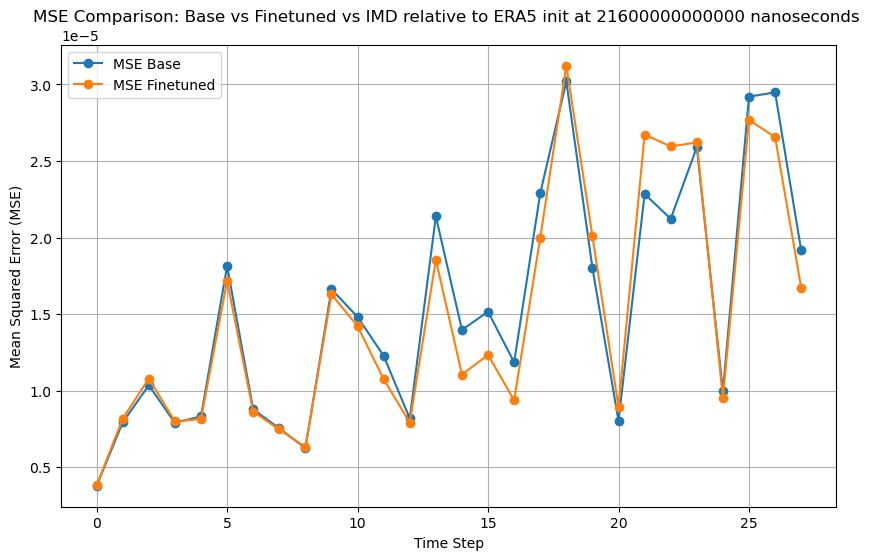

In [ ]:
def compute_mse(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values
# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

print(mse_base)
print(mse_finetuned)

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

# Annotate the first and last points for MSE Base

# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
print(sum(mse_base))
print(sum(mse_finetuned))

0.0004300535169932118
0.00041850752268146607


In [ ]:
imd_jun23_forecast = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imd_tigge_2023_07.grib')
imd_jun23_forecast

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 290MB
Dimensions:     (time: 31, step: 9, latitude: 361, longitude: 720)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2023-07-01 2023-07-02 ... 2023-07-31
  * step        (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    tp          (time, step, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-06-24T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
select_time_eval.datetime.values[0]

array(['2023-07-01T00:00:00.000000000', '2023-07-01T06:00:00.000000000',
       '2023-07-01T12:00:00.000000000', '2023-07-01T18:00:00.000000000',
       '2023-07-02T00:00:00.000000000', '2023-07-02T06:00:00.000000000',
       '2023-07-02T12:00:00.000000000', '2023-07-02T18:00:00.000000000',
       '2023-07-03T00:00:00.000000000', '2023-07-03T06:00:00.000000000',
       '2023-07-03T12:00:00.000000000', '2023-07-03T18:00:00.000000000',
       '2023-07-04T00:00:00.000000000', '2023-07-04T06:00:00.000000000',
       '2023-07-04T12:00:00.000000000', '2023-07-04T18:00:00.000000000',
       '2023-07-05T00:00:00.000000000', '2023-07-05T06:00:00.000000000',
       '2023-07-05T12:00:00.000000000', '2023-07-05T18:00:00.000000000',
       '2023-07-06T00:00:00.000000000', '2023-07-06T06:00:00.000000000',
       '2023-07-06T12:00:00.000000000', '2023-07-06T18:00:00.000000000',
       '2023-07-07T00:00:00.000000000', '2023-07-07T06:00:00.000000000',
       '2023-07-07T12:00:00.000000000', '2023-07-07

In [ ]:
init_date = select_time_eval.datetime.values[0][0]

In [ ]:
init_date

numpy.datetime64('2023-07-01T00:00:00.000000000')

In [ ]:
imd_jun23_temp = imd_jun23_forecast.sel(time=init_date)
imd_jun23_temp

<xarray.Dataset> Size: 9MB
Dimensions:     (step: 9, latitude: 361, longitude: 720)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2023-07-01
  * step        (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    valid_time  (step) datetime64[ns] 72B ...
Data variables:
    tp          (step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-06-24T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
imd_6h_converted = ( imd_jun23_temp.isel(step=0+1) ['tp'] - imd_jun23_temp.isel(step=0) ['tp'] )/1000

In [1]:
import xarray as xr
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2022/hres_2022_8_1_ppt.grib')
hres

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 06:00:00 ... 1 days 18:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-11T20:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)
regridded_hres

Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


<xarray.DataArray 'tp' (step: 8, lat: 181, lon: 360)> Size: 2MB
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
...
        [4.6539307e-04, 4.6539307e-04, 4.8828125e-04, ...,
         4.1198730e-04, 4.1198730e-04, 4.6539307e-04],
        [2.5177002e-04, 2.5177002e-04, 2.5177002e-04, ...,
         2.4414062e-04, 2.5177002e-04, 2.5177002e-04],
        [2.5177002e-04, 2.5177002e-04, 2.5177002e-04, ...,
         2.5177002e-04, 2.5177002e-04, 2.5177002e-04]],

       [[2.9754639e-04, 2.9754639e-04, 2.9754639e-04, ...,
         2.9754639e-04, 2.9754639e-04, 2.9754639e-04],
        [3.5095215e-04, 3.5095215e-04, 3.5095215e-04, ...,
         3.4332275e-04, 3.5095215e-04, 3.5095215e-04],
        [3.9672852e-04, 3.9672852e-04, 3.8909912e-04, ...,
         3.9672852e-04, 3.9672852e-04, 3.9672852e-04],
        ...,
        [5.0354004e-04, 5.0354004e-04, 5.1116943e-04, ...,
         4.5776367e-04, 4.5776367e-04, 5.0354004e-04],
        [4.3487549e-04, 4.3487549e-04, 4.3487549e-04, ...,
         4.4250488e-04, 4.3487549e-04, 4.3487549e-04],
        [3.1280518e-04, 3.1280518e-04, 3.1280518e-04, ...,
         3.1280518e-04, 3.1280518e-04, 3.1280518e-04]]], dtype=float32)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2022-08-01
  * step        (step) timedelta64[ns] 64B 00:00:00 06:00:00 ... 1 days 18:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2022-08-01 ... 2022-08-02T18:00:00
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             6599680
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d


Shape of the 6-hour forecast data from ds1: (181, 360)
Shape of the hourly 'tp' data from ds2: (8, 181, 360)

Step 3: Calculating Mean Squared Error per step...

Calculated MSE for each step:
<xarray.DataArray (step: 8)> Size: 64B
array([1.59605183e-07, 3.42381869e-07, 8.06818294e-07, 1.51353187e-06,
       2.44103698e-06, 3.59758161e-06, 4.86975060e-06, 6.30794471e-06])
Coordinates:
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    number      int64 8B 0
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2022-07-01 ... 2022-07-01T07:00:00

Step 4: Plotting the results...


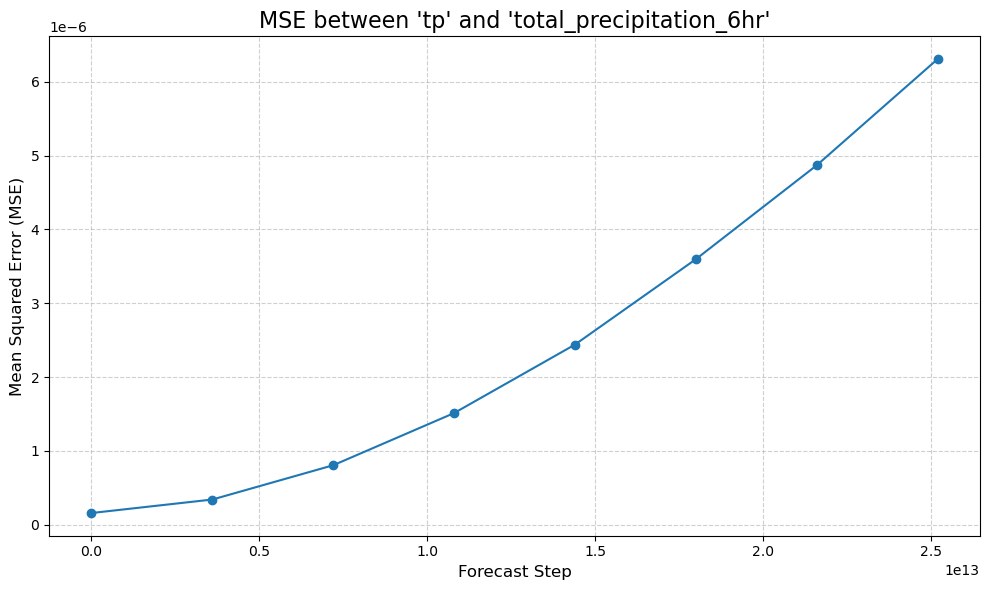

In [ ]:
precip_ds1 = eval_targets['total_precipitation_6hr']

# Select the data at the 6-hour mark.
# We use .sel() to select by coordinate value.
six_hour_forecast = precip_ds1.sel(time=pd.to_timedelta('6 hours'))

# The result has a 'batch' dimension of size 1. We remove it with .squeeze()
# so its dimensions (lat, lon) match the spatial dimensions of ds2.
six_hour_forecast_squeezed = six_hour_forecast.squeeze('batch')

# The second dataset is already our target variable 'tp'
precip_ds2 = regridded_hres

print("\nShape of the 6-hour forecast data from ds1:", six_hour_forecast_squeezed.shape)
print("Shape of the hourly 'tp' data from ds2:", precip_ds2.shape)


# --- 3. Compute the Mean Squared Error (MSE) ---
print("\nStep 3: Calculating Mean Squared Error per step...")

# Xarray will automatically align and broadcast the 'six_hour_forecast_squeezed' array
# across the 'step' dimension of 'precip_ds2' during the subtraction.
squared_error = (six_hour_forecast_squeezed - precip_ds2)**2

# Now, compute the mean over the spatial dimensions ('lat', 'lon') to get
# a single MSE value for each step.
mse_per_step = squared_error.mean(dim=['lat', 'lon'])

print("\nCalculated MSE for each step:")
print(mse_per_step)


# --- 4. Plot the Results ---
print("\nStep 4: Plotting the results...")

# Create the plot
plt.figure(figsize=(10, 6))

# Use xarray's built-in plotting for a quick and easy line plot
mse_per_step.plot.line(marker='o', linestyle='-')

# Customize the plot for clarity
plt.title("MSE between 'tp' and 'total_precipitation_6hr'", fontsize=16)

# The step coordinate is a timedelta; we can format the x-axis for readability
# by getting the total hours from the timedelta coordinate.
x_labels = mse_per_step.step.dt.total_seconds() / 3600
# plt.xticks(mse_per_step.step, labels=[f'{int(h)}h' for h in x_labels])
plt.xlabel("Forecast Step", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
mse_per_step.values

array([1.59605183e-07, 3.42381869e-07, 8.06818294e-07, 1.51353187e-06,
       2.44103698e-06, 3.59758161e-06, 4.86975060e-06, 6.30794471e-06])

In [ ]:
import cartopy.crs as ccrs
import xarray as xr



def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg_2.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg_2.png')
    plt.close()

    return (difference)


def plot_diff_imd_era5_sims(pred_imd, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # if var_name == 'total_precipitation_6hr':
    #     pred_imd = preds_old['tp']
        
    temperature_targets = targets[var_name]

    # imd lat order is reversed

    pred_imd = pred_imd.rename({'latitude': 'lat', 'longitude': 'lon'})
    temp_imd = pred_imd.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step,batch=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_imd - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"IMD Prediction vs Ground Truth at Time Step {time_step} for {var_name}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_imd_era5_{var_name}_2.png')
    plt.close()

    return (difference)

In [ ]:
diff_fine, diff_old, diff_imd = [], [], []

In [ ]:
for time_step in tqdm(range(4)):
    diff_fine.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, 'total_precipitation_6hr'))
    diff_old.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr'))
    diff_imd.append(plot_diff_imd_era5_sims(imd_6h_converted,eval_targets,time_step, 'total_precipitation_6hr'))


100%|██████████| 4/4 [00:01<00:00,  2.69it/s]


In [ ]:
def compute_mse(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

[array(1.30338009e-06), array(9.66576661e-06), array(1.04822204e-05), array(1.28963753e-05)]
[array(nan), array(nan), array(nan), array(nan)]


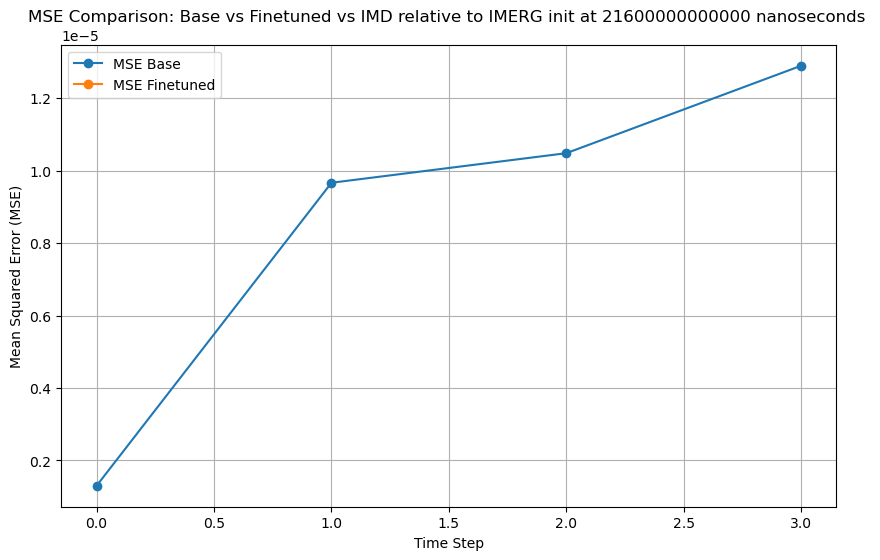

In [ ]:
# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

# print(mse_base)
# print()
# print(mse_finetuned)


print(mse_base)
print(mse_finetuned)




# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(4)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(4)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

    # Annotate the first and last points for MSE Base
# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to IMERG init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
mse_diff_finetuned = compute_mse_diffs(a)
mse_diff_base = compute_mse_diffs(b)
mse_diff_imd_era5 = compute_mse_diffs(c)